In [ ]:
# !pip install matplotlib

In [ ]:
# pip list yfinance

In [ ]:
import yfinance as yf

ticker = yf.Ticker("TCS.NS")

# Historical prices
hist = ticker.history(period="6mo")

# Company info
info = ticker.info
print(info['currentPrice'], info['trailingPE'], info['marketCap'], info['sector'], info['returnOnEquity']
)
first_close = hist["Close"].iloc[0]   # first row
last_close = hist["Close"].iloc[-1]

return_percent = ((last_close - first_close) / first_close) * 100

print(f"TCS 6-month return: {return_percent:.2f}%")

In [ ]:
import yfinance as yf


def get_nifty_data():
    index=["^NSEI","^NSEBANK"]

    dict = {}
    for i in index:
        ticker = yf.Ticker(i)

    # Historical prices
        hist = ticker.history(period="1mo")

        first_close = float(hist["Close"].iloc[0] )  # first row
        last_close = round(float(hist["Close"].iloc[-1]), 2)
        return_percent = round(((last_close - first_close) / first_close * 100), 2)

        dict.setdefault(i, []).append(last_close)
        dict.setdefault(i, []).append(return_percent)

    return dict
# Company info
# info = ticker.info
# hist

get_nifty_data()

In [ ]:
import time
def get_nifty_data():
    """

    Fetch Current Nifty 50 index level and 1-month return.
    Use this to understand broader Indian Market Direction.
    """
    try:

        index = {
        "^NSEI": "NIFTY 50",
        "^NSEBANK": "NIFTY Bank"
        }

        lines =[]
        for i in index:
            time.sleep(2)
            ticker = yf.Ticker(i)

        # Historical prices
            hist = ticker.history(period="1mo")

            first_close = float(hist["Close"].iloc[0] )  # first row
            last_close = round(float(hist["Close"].iloc[-1]), 2)
            return_percent = round(((last_close - first_close) / first_close * 100), 2)

            lines.append(f"{index[i]}: ₹{last_close} | 1M Return: {return_percent}%")
    except Exception as e:
        return f"Error fetching Nifty data: {str(e)}"
    return "\n".join(lines)

get_nifty_data()

In [ ]:
import feedparser
url = "https://economictimes.indiatimes.com/markets/stocks/rssfeeds/2146842.cms"
feed = feedparser.parse(url)

print(feed.status)        # should be 200
print(len(feed.entries))  # how many articles came back
print(feed.feed)          # feed metadata

# First just print all titles to understand the structure
for entry in feed.entries[:5]:
    print(entry.title)

In [ ]:
import feedparser

url = "https://economictimes.indiatimes.com/markets/stocks/rssfeeds/2146842.cms"
feed = feedparser.parse(url)

print("Entries:", len(feed.entries))
for entry in feed.entries:
    print(entry.title)

In [ ]:
import feedparser
import pandas as pd

rss_urls = [
"https://economictimes.indiatimes.com/markets/rssfeeds/1977021501.cms",
"https://www.moneycontrol.com/rss/stocks.xml",
"https://www.livemint.com/rss/markets"
]

data=[]

for url in rss_urls:
    feed = feedparser.parse(url)

    for entry in feed.entries:
        data.append({
            "title":entry.title,
            "summary":entry.summary if "summary" in entry else "",
            "published":entry.published,
            "link":entry.link
        })

df=pd.DataFrame(data)


stock_map = {
"TCS":"TCS",
"Reliance":"RELIANCE",
"HDFC":"HDFCBANK",
"Infosys":"INFY"
}

def detect_stock(text):
    for k in stock_map:
        if k.lower() in text.lower():
            return stock_map[k]
    return None

df["stock"]=df["title"].apply(detect_stock)

df

# from transformers import pipeline

# sentiment_model = pipeline(
# "sentiment-analysis",
# model="ProsusAI/finbert"
# )

# df["sentiment"]=df["title"].apply(lambda x: sentiment_model(x)[0]["label"])
# df["score"]=df["title"].apply(lambda x: sentiment_model(x)[0]["score"])


# sentiment_map = {
# "positive":1,
# "neutral":0,
# "negative":-1
# }

# df["sentiment_value"]=df["sentiment"].map(sentiment_map)

# stock_sentiment=df.groupby("stock")["sentiment_value"].mean()

In [ ]:
def get_stock_news(symbol: str) -> str:
    """Fetch recent news for an Indian stock from Economic Times.
    Input: stock name like TCS, Reliance, Infosys or any listed stock on NSE or BSE.
    """
    lines = []
    urls = [
        "https://economictimes.indiatimes.com/markets/stocks/rssfeeds/2146842.cms"
        "https://economictimes.indiatimes.com/markets/rssfeeds/1977021501.cms",
        "https://economictimes.indiatimes.com/markets/expert-view/rssfeeds/50649960.cms",

        # Company News
        "https://economictimes.indiatimes.com/news/company/rssfeeds/2143429.cms",

        # Industry
        "https://economictimes.indiatimes.com/industry/rssfeeds/13352306.cms",
        "https://www.business-standard.com/rss/markets-106.rss",

# Mint
        "https://www.livemint.com/rss/markets",

# Moneycontrol
        "https://www.moneycontrol.com/rss/business.xml"
    ]
# You know this
    for url in urls:
        feed = feedparser.parse(url)

        # You know this
        for entry in feed.entries:
            if symbol.lower() in entry.title.lower():

                lines.append(f"Title: {entry.title}")
                lines.append(f"\nSummary: {entry.summary if 'summary' in entry else ''}")
                lines.append(f"\nLink: {entry.link}")
    return "\n".join(lines)

get_stock_news("TCS")

In [ ]:
feed = feedparser.parse("https://economictimes.indiatimes.com/markets/stocks/rssfeeds/2146842.cms")
entry = feed.entries[0]
print(entry.keys())

In [ ]:
entry.title

In [ ]:
entry.summary

In [ ]:
import yfinance as yf
ticker = yf.Ticker("TCS.NS")
" ".join(i for i in ticker.info['longName'].split()[:2])

In [ ]:
from tools import nse_tools

print(nse_tools.get_stock_news.invoke({"symbol": "TCS"}))
print(nse_tools.get_stock_news.invoke({"symbol": "INFY"}))

print(nse_tools.get_stock_news.invoke({"symbol": "RELIANCE"}))

In [ ]:
print(nse_tools.get_technical_analysis.invoke({"symbol": "TCS"}))

In [ ]:
import requests
"""Fetch latest FII and DII data for Indian stock market from Economic Times."""
url = "https://www.nseindia.com/api/fiidiiTradeReact"
headers = {
"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
"Accept": "application/json",
"Referer": "https://www.nseindia.com/",
}

session = requests.Session()
session.headers.update(headers)
session.get("https://www.nseindia.com", timeout=10)  # get cookies first
response = session.get(url, timeout=15)
data = response.json()
data

In [ ]:
import requests

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept": "application/json",
    "Referer": "https://www.nseindia.com/",
}

session = requests.Session()
session.headers.update(headers)
session.get("https://www.nseindia.com", timeout=10)

response = session.get("https://www.nseindia.com/api/fiidiiTradeReact", timeout=15)
print(response.status_code)
print(response.json()[0])

In [ ]:
url = "https://www.nseindia.com/api/fiidiiTradeReact"
headers = {
"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
"Accept": "application/json",
"Referer": "https://www.nseindia.com/",
}

session = requests.Session()
session.headers.update(headers)
session.get("https://www.nseindia.com", timeout=10)  # get cookies first
response = session.get(url, timeout=15)
data = response.json()
print(data)

for record in data:
    if record['category'] == 'FII/FPI':
        fii_net = float(record['netValue'])
        fii_signal = "Net Buyer" if fii_net > 0 else "Net Seller"
        fii_date = record['date']
    elif record['category'] == 'DII':
        dii_net = float(record['netValue'])
        dii_signal = "Net Buyer" if dii_net > 0 else "Net Seller"
        dii_date = record['date']
print(f"FII: {fii_signal} ₹{abs(fii_net):,.2f} on {fii_date}")
print(f"DII: {dii_signal} ₹{abs(dii_net):,.2f} on {dii_date}")

In [ ]:
from tools import nse_tools
nse_tools.get_fii_dii_data.invoke({})

In [ ]:
import yfinance as yf
ticker = yf.Ticker("TCS.NS")
sector = ticker.info['sector']
print(ticker.info['marketCap'])

market_cap = ticker.info['marketCap']

if market_cap > 20000_00_00000:  # 20,000 Cr in rupees
    cap_category = "Large Cap"
    cap_index = "^CNX100"
elif market_cap > 5000_00_00000:  # 5,000 Cr
    cap_category = "Mid Cap"
    cap_index = "^NSEMDCP50"
else:
    cap_category = "Small Cap"
    cap_index = "^CNXSC"

cap_category

from tools import config
print(config.INDEX_SYMBOLS)
print(config.SECTOR_TO_INDEX)
print(config.CAP_TO_INDEX)

 # Step 4: calculate 6mo return for:
    #         → stock
    #         → NIFTY 50 (always)
    #         → sector index
    #         → cap index


ticker = yf.Ticker("TCS.NS")

# Historical prices
hist = ticker.history(period="6mo")
first_close = hist["Close"].iloc[0]   # first row
last_close = hist["Close"].iloc[-1]
stock_return = ((last_close - first_close) / first_close) * 100
print(f"TCS 6-month return: {stock_return:.2f}%")

ticker = yf.Ticker("^NSEI")
hist = ticker.history(period="6mo")
first_close = hist["Close"].iloc[0]   # first row
last_close = hist["Close"].iloc[-1]
nifty_return = ((last_close - first_close) / first_close) * 100
print(f"NIFTY 50 6-month return: {nifty_return:.2f}%")


sector_index=config.INDEX_SYMBOLS[config.SECTOR_TO_INDEX[sector]]
print(f"Using {sector_index} for {sector} sector")
ticker = yf.Ticker(sector_index)
hist = ticker.history(period="6mo")
first_close = hist["Close"].iloc[0]   # first row
last_close = hist["Close"].iloc[-1]
sector_return = ((last_close - first_close) / first_close) * 100
print(f"{config.SECTOR_TO_INDEX['Technology']} 6-month return: {sector_return:.2f}%")


## cap _idnex
cap_index=config.INDEX_SYMBOLS[config.CAP_TO_INDEX[cap_category]]
print(f"Using {cap_index} for {cap_category} category")
ticker = yf.Ticker(cap_index)
hist = ticker.history(period="6mo")
first_close = hist["Close"].iloc[0]   # first row
last_close = hist["Close"].iloc[-1]
cap_return = ((last_close - first_close) / first_close) * 100
print(f"{cap_category} index 6-month return: {cap_return:.2f}%")

   # Step 5: compare + interpret

    # Step 6: return string

diff = stock_return - nifty_return
if diff > 0:
    nifty_signal = f"Outperformed NIFTY 50 by {diff:.2f}%"
else:
    nifty_signal = f"Underperformed NIFTY 50 by {abs(diff):.2f}%"

diff = stock_return - sector_return
if diff > 0:
    sector_signal = f"Outperformed {config.SECTOR_TO_INDEX[sector]} sector index by {diff:.2f}%"
else:
    sector_signal = f"Underperformed {config.SECTOR_TO_INDEX[sector]} sector index by {abs(diff):.2f}%"

diff = stock_return - cap_return
if diff > 0:
    cap_signal = f"Outperformed {cap_category} index by {diff:.2f}%"
else:
    cap_signal = f"Underperformed {cap_category} index by {abs(diff):.2f}%"

print(f"{nifty_signal}\n{sector_signal}\n{cap_signal}")



In [ ]:
from tools import nse_tools
print(nse_tools.get_relative_strength.invoke({"symbol": "TCS"}))

In [ ]:
import pandas as pd

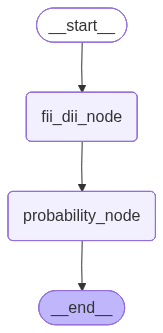

Graph saved to graph/workflow_graph.png
  [fpi_node] daily → MIXED  FII ₹-2,714  DII ₹3,253

════════════════════════════════════════════════════════════
  FPI Pipeline  |  19-Mar-2026
════════════════════════════════════════════════════════════

▶  detect_dates

▶  fetch_reports

▶  parse_tables

▶  extract_data

▶  generate_insights

════════════════════════════════════════════════════════════════════════════════════════════════════════════
  📊  FPI INSIGHTS  |   → Mar152026
════════════════════════════════════════════════════════════════════════════════════════════════════════════
  F1: ₹      +8,095 Cr   F2: ₹     -60,267 Cr   Month: ₹     -52,172 Cr   Signal: STRONG SELL
  Equity: ₹     -49,763 Cr   Debt: ₹      +1,489 Cr   Change vs Prev: ₹   -52,172 Cr
  Buying: 6 sectors  |  Selling: 18 sectors

────────────────────────────────────────────────────────────────────────────────────────────────────────────
   #  Sector                                          F1          F2        

In [1]:
from graph import workflow





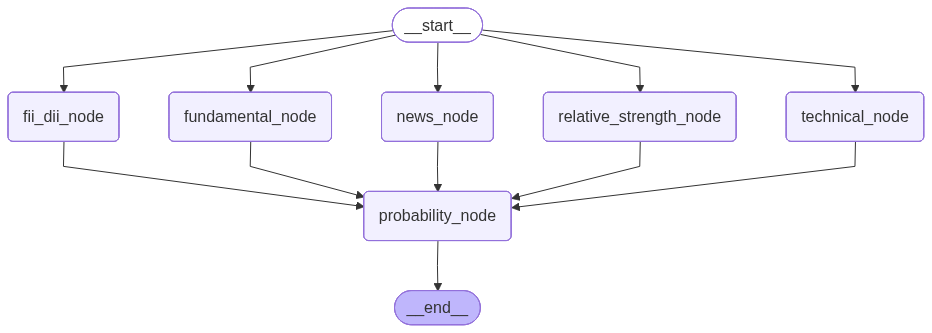

Graph saved to graph/workflow_graph.png
  [fpi_node] daily → MIXED  FII ₹-5,518  DII ₹5,706

════════════════════════════════════════════════════════════
  FPI Pipeline  |  20-Mar-2026
════════════════════════════════════════════════════════════

▶  detect_dates

▶  fetch_reports

▶  parse_tables

▶  extract_data

▶  generate_insights

════════════════════════════════════════════════════════════════════════════════════════════════════════════
  📊  FPI INSIGHTS  |   → Mar152026
════════════════════════════════════════════════════════════════════════════════════════════════════════════
  F1: ₹      +8,095 Cr   F2: ₹     -60,267 Cr   Month: ₹     -52,172 Cr   Signal: STRONG SELL
  Equity: ₹     -49,763 Cr   Debt: ₹      +1,489 Cr   Change vs Prev: ₹   -52,172 Cr
  Buying: 6 sectors  |  Selling: 18 sectors

────────────────────────────────────────────────────────────────────────────────────────────────────────────
   #  Sector                                          F1          F2        

[*********************100%***********************]  1 of 1 completed

technical score 40
technical analysis {'score': 40, 'trend': 'Bearish', 'signals': ['Price below 20 DMA', 'MACD Bearish', 'RSI Neutral'], 'summary': 'The price is below the 20-day moving average and the MACD is bearish, indicating a short-term bearish trend. However, the price remains above the 50, 100, and 200-day moving averages, providing long-term support.'}



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

fundamental score 70
fundamental analysis {'score': 70, 'profitability': 'Moderate', 'growth': 'Moderate', 'valuation': 'Overvalued', 'risk': 'Medium', 'summary': "TORNTPHARM.NS has moderate profitability and growth, but its high P/E ratio suggests overvaluation. The company's debt to equity and interest coverage ratios indicate a medium level of risk."}



[*********************100%***********************]  1 of 1 completed


{'symbol': 'TORNTPHARM', 'period': '6 months', 'nifty_50': {'return_diff': np.float64(25.88), 'rs_growth': np.float64(28.23), 'signal': 'Strong Outperformance'}, 'sector': {'return_diff': np.float64(16.82), 'rs_growth': np.float64(16.69), 'signal': 'Strong Outperformance'}, 'market_cap': {'return_diff': np.float64(25.96), 'rs_growth': np.float64(28.33), 'signal': 'Strong Outperformance'}}
relative score 100
relative analysis {'score': 100, 'momentum': 'Strong', 'market_view': 'Outperforming', 'signals': ['Strong outperformance vs NIFTY 50 with 25.88% return difference', 'Strong outperformance vs sector index with 16.82% return difference', 'Strong outperformance vs market cap index with 25.96% return difference'], 'summary': 'TORNTPHARM has shown strong outperformance across all benchmarks over the last 6 months, indicating very strong momentum and leadership in its sector and market cap category', 'confidence': 'High'}
news score 60
news analysis {'score': 60, 'sentiment': 'Neutral', 

In [1]:
from graph.workflow import app

result = app.invoke({
    "symbol": "TORNTPHARM",
    "fundamental_data": "",
    "technical_data": "",
    "news_data": "",
    "fii_dii_data": "",
    "relative_strength": "",
    "relative_data": "",
    "fundamental_score": 0,
    "technical_score": 0,
    "news_score": 0,
    "fii_dii_score": 0,
    "fpi_score": 0,
    "relative_strength_score": 0,
    "relative_score": 0,
    "fundamental_analysis": None,
    "technical_analysis": None,
    "news_analysis": None,
    "fii_dii_analysis": None,
    "fpi_analysis": None,
    "fpi_raw": None,
    "relative_strength_analysis": None,
    "relative_analysis": None,
    "probability_score": "",
    "final_score": 0,
    "signal": "",
    "confidence": 0,
    "report": "",
})

# Print final report
print(result["report"])
print(result.keys())
print(result)
print(f"\nSignal: {result['signal']}")
print(f"Score: {result['final_score']}")
print(f"Confidence: {result['confidence']}%")

In [ ]:

def get_stock_news(symbol: str) -> str:
    """
    Hybrid News Fetcher:
    - Tavily (semantic search)
    - Google News (broad coverage)
    - Indian RSS sources (trusted)
    """

    import yfinance as yf
    import feedparser
    from urllib.parse import quote
    from tavily import TavilyClient

    # -------------------------
    # Setup
    # -------------------------
    tavily = TavilyClient(api_key="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")

    ticker_input = symbol + ".NS"
    ticker = yf.Ticker(ticker_input)

    long_name = ticker.info.get("longName", symbol)

    # Clean company name
    remove_words = ["Limited", "Ltd", "Ltd.", "Company", "Corporation"]
    for word in remove_words:
        long_name = long_name.replace(word, "").strip()

    short_name = " ".join(long_name.split()[:2])

    lines = []

    # =========================================================
    # 1️⃣ Tavily (HIGH QUALITY SEARCH)
    # =========================================================
    try:
        tavily_results = tavily.search(
            query=f"{long_name} stock news India latest",
            search_depth="advanced",
            max_results=5
        )

        for res in tavily_results.get("results", []):
            lines.append(f"[Tavily] {res.get('content')}")

    except Exception as e:
        lines.append(f"[Tavily Error] {str(e)}\n")

    # =========================================================
    # 2️⃣ Google News RSS (REAL-TIME)
    # =========================================================
    try:
        encoded_query = quote(long_name + " stock india")
        url = f"https://news.google.com/rss/search?q={encoded_query}&hl=en-IN&gl=IN&ceid=IN:en"

        feed = feedparser.parse(url)

        for entry in feed.entries[:5]:
            lines.append(f"[Google] {entry.title}")


    except Exception as e:
        lines.append(f"[Google Error] {str(e)}\n")

    # =========================================================
    # 3️⃣ YOUR RSS SOURCES (TRUSTED INDIAN NEWS)
    # =========================================================
    urls = [
        "https://economictimes.indiatimes.com/markets/stocks/rssfeeds/2146842.cms",
        "https://economictimes.indiatimes.com/markets/rssfeeds/1977021501.cms",
        "https://economictimes.indiatimes.com/markets/expert-view/rssfeeds/50649960.cms",
        "https://economictimes.indiatimes.com/news/company/rssfeeds/2143429.cms",
        "https://economictimes.indiatimes.com/industry/rssfeeds/13352306.cms",
        "https://www.business-standard.com/rss/markets-106.rss",
        "https://www.livemint.com/rss/markets",
        "https://www.moneycontrol.com/rss/business.xml"
    ]

    try:
        for url in urls:
            feed = feedparser.parse(url)

            for entry in feed.entries:
                title = entry.title.lower()

                if (
                    symbol.lower() in title
                    or short_name.lower() in title
                    or long_name.lower() in title
                ):
                    lines.append(f"[RSS] {entry.title}")

    except Exception as e:
        lines.append(f"[RSS Error] {str(e)}\n")

    # =========================================================
    # 4️⃣ REMOVE DUPLICATES (IMPORTANT)
    # =========================================================
    unique_lines = list(dict.fromkeys(lines))

    return "\n".join(unique_lines)  # limit output

data=get_stock_news("TCS")

https://economictimes.indiatimes.com/tata-consultancy-services-ltd/stocks/companyid-8345.cms

In [ ]:
from tavily import TavilyClient

tavily = TavilyClient(api_key="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")


lines=[]
tavily_results = tavily.search(
    query=f"Tata consultancy stock latest news",
    search_depth="advanced",
    max_results=5
)

for res in tavily_results.get("results", []):
    lines.append(f"[Tavily] {res.get('title')}")
    lines.append(f"{res.get('url')}\n")
lines

In [ ]:
k = []
for i in tavily_results['results']:
    k.append(i['content'])


In [ ]:
from urllib.parse import quote

encoded_query = quote("Tata Consultancy" + " stock india")
url = f"https://news.google.com/rss/search?q={encoded_query}&hl=en-IN&gl=IN&ceid=IN:en"

feed = feedparser.parse(url)
print(feed.items())
lines= []
for entry in feed.entries[:5]:
    lines.append(f"[Google] {entry.title}")
    # lines.append(f"{entry.link}\n")
lines

In [ ]:
import yfinance as yf
import pandas as pd

stock_symbol = "TCS.NS"
index_symbol = "^NSEI"
stock = yf.download(stock_symbol, period="6mo")["Close"]
index = yf.download(index_symbol, period="6mo")["Close"]

print(stock)
print(index)

# # RS ratio
# df["RS"] = df["stock"] / df["index"]

# # Normalize
# df["RS_norm"] = (df["RS"] / df["RS"].iloc[0]) * 100

# # Trend
# df["RS_MA"] = df["RS_norm"].rolling(20).mean()

# latest = df.iloc[-1]
stock

In [ ]:
# -------------------------
from langchain_core.messages import HumanMessage

from graph.llm import get_llm
import json
prompt = f"""
    You are a professional financial news sentiment analyst.

    Analyze the structured news data below.

    IMPORTANT THINKING STEPS:
    - Focus on earnings, results, deals, regulations
    - Ignore generic market noise
    - Give higher weight to repeated themes

    TASK:
    1. Determine overall sentiment
    2. Score (0–100)
    3. Extract key signals

    STRICT OUTPUT: JSON ONLY

    Format:
    {{
        "score": <number>,
        "sentiment": "Bullish / Neutral / Bearish",
        "key_points": [
            "concise insight 1",
            "concise insight 2"
        ],
        "summary": "2-3 line professional explanation",
        "confidence": "High / Medium / Low"
    }}

    Structured News:
    {data}
    """
llm=get_llm()
response = llm.invoke([HumanMessage(content=prompt)])
response

In [ ]:
print(tavily_results)

In [ ]:
# ==========================================
# FINAL: Robust Fundamental Analysis Script
# ==========================================

import yfinance as yf
import pandas as pd

# -------------------------------
# Helper: Safe extractor
# -------------------------------
def safe_get(df, keys):
    try:
        for key in keys:
            if key in df.index:
                return df.loc[key].iloc[0]
    except Exception:
        pass
    return None


# -------------------------------
# Core Function
# -------------------------------
def get_fundamentals(ticker):
    try:
        stock = yf.Ticker(ticker)

        info = stock.info
        income = stock.financials
        balance = stock.balance_sheet

        # -------------------------
        # Try extracting from statements
        # -------------------------
        net_income = safe_get(income, ["Net Income", "NetIncome"])
        equity = safe_get(balance, ["Total Stockholder Equity", "Stockholders Equity"])
        total_assets = safe_get(balance, ["Total Assets"])
        debt = safe_get(balance, ["Total Debt", "Long Term Debt"])
        ebit = safe_get(income, ["Ebit", "EBIT"])
        interest_expense = safe_get(income, ["Interest Expense"])
        revenue = safe_get(income, ["Total Revenue"])

        # -------------------------
        # Compute ratios (with fallback)
        # -------------------------
        roe = (net_income / equity) if net_income and equity else info.get("returnOnEquity")
        roa = (net_income / total_assets) if net_income and total_assets else info.get("returnOnAssets")
        debt_to_equity = (debt / equity) if debt and equity else info.get("debtToEquity")

        asset_turnover = (revenue / total_assets) if revenue and total_assets else None

        interest_coverage = (
            ebit / abs(interest_expense)
            if ebit and interest_expense and interest_expense != 0
            else None
        )

        # -------------------------
        # Direct from info
        # -------------------------
        data = {
            "Ticker": ticker,
            "PE": info.get("trailingPE"),
            "Forward_PE": info.get("forwardPE"),
            "PB": info.get("priceToBook"),
            "EV_EBITDA": info.get("enterpriseToEbitda"),

            "ROE": roe,
            "ROA": roa,
            "Debt_to_Equity": debt_to_equity,
            "Interest_Coverage": interest_coverage,
            "Asset_Turnover": asset_turnover,

            "Profit_Margin": info.get("profitMargins"),
            "Operating_Margin": info.get("operatingMargins"),

            "Revenue_Growth": info.get("revenueGrowth"),
            "Earnings_Growth": info.get("earningsGrowth"),
        }

        return data

    except Exception as e:
        print(f"Error: {ticker} -> {e}")
        return None


# -------------------------------
# Analyze Multiple Stocks
# -------------------------------
def analyze_stocks(tickers):
    data = []

    for t in tickers:
        print(f"Fetching: {t}")
        res = get_fundamentals(t)
        if res:
            data.append(res)

    df = pd.DataFrame(data)

    # -------------------------
    # Handle Missing Values (IMPORTANT)
    # -------------------------
    df = df.fillna({
        "ROE": 0,
        "ROA": 0,
        "Debt_to_Equity": df["Debt_to_Equity"].max(),
        "Profit_Margin": 0,
        "Revenue_Growth": 0
    })

    # -------------------------
    # Scoring Model
    # -------------------------
    df["Score"] = (
        df["ROE"].rank(ascending=False) +
        df["ROA"].rank(ascending=False) +
        df["Profit_Margin"].rank(ascending=False) +
        df["Revenue_Growth"].rank(ascending=False) -
        df["Debt_to_Equity"].rank(ascending=True)
    )

    return df.sort_values(by="Score")


# -------------------------------
# Interpretation Layer
# -------------------------------
def interpret(row):
    insights = []

    if row["ROE"] > 0.18:
        insights.append("Excellent ROE")

    if row["ROA"] > 0.08:
        insights.append("Efficient Assets")

    if row["Debt_to_Equity"] < 1:
        insights.append("Low Debt")

    if row["Interest_Coverage"] and row["Interest_Coverage"] > 3:
        insights.append("Safe Debt")

    if row["Revenue_Growth"] > 0.1:
        insights.append("Growing Business")

    if row["PE"] and row["PE"] > 40:
        insights.append("High Valuation")

    return ", ".join(insights)


# -------------------------------
# MAIN
# -------------------------------
if __name__ == "__main__":

    tickers = [
        "RELIANCE.NS",
        "TCS.NS",
        "INFY.NS",
        "HDFCBANK.NS",
        "ICICIBANK.NS"
    ]

    print("\nStarting Analysis...\n")

    df = analyze_stocks(tickers)

    df["Insights"] = df.apply(interpret, axis=1)

    pd.set_option("display.max_columns", None)
    print("\nFinal Result:\n")
    print(df)

    # Save output
    df.to_csv("final_fundamental_analysis.csv", index=False)

    print("\nSaved: final_fundamental_analysis.csv")

In [ ]:
import yfinance as yf

# -------------------------------
# Helper: Safe extractor
# -------------------------------
def safe_get(df, keys):
    try:
        for key in keys:
            if key in df.index:
                return df.loc[key].iloc[0]
    except Exception:
        pass
    return None


# -------------------------------
# Main Function (Single Stock)
# -------------------------------
def analyze_stock(ticker):
    stock = yf.Ticker(ticker)

    info = stock.info
    income = stock.financials
    balance = stock.balance_sheet

    # Extract values safely
    net_income = safe_get(income, ["Net Income", "NetIncome"])
    equity = safe_get(balance, ["Total Stockholder Equity", "Stockholders Equity"])
    total_assets = safe_get(balance, ["Total Assets"])
    debt = safe_get(balance, ["Total Debt", "Long Term Debt"])
    ebit = safe_get(income, ["Ebit", "EBIT"])
    interest_expense = safe_get(income, ["Interest Expense"])
    revenue = safe_get(income, ["Total Revenue"])

    # Ratios with fallback
    roe = (net_income / equity) if net_income and equity else info.get("returnOnEquity")
    roa = (net_income / total_assets) if net_income and total_assets else info.get("returnOnAssets")
    debt_to_equity = (debt / equity) if debt and equity else info.get("debtToEquity")

    asset_turnover = (revenue / total_assets) if revenue and total_assets else None

    interest_coverage = (
        ebit / abs(interest_expense)
        if ebit and interest_expense and interest_expense != 0
        else None
    )

    # Final Output
    result = {
        "Ticker": ticker,
        "PE": info.get("trailingPE"),
        "Forward_PE": info.get("forwardPE"),
        "PB": info.get("priceToBook"),
        "EV_EBITDA": info.get("enterpriseToEbitda"),

        "ROE": roe,
        "ROA": roa,
        "Debt_to_Equity": debt_to_equity,
        "Interest_Coverage": interest_coverage,
        "Asset_Turnover": asset_turnover,

        "Profit_Margin": info.get("profitMargins"),
        "Operating_Margin": info.get("operatingMargins"),

        "Revenue_Growth": info.get("revenueGrowth"),
        "Earnings_Growth": info.get("earningsGrowth"),
    }

    return result


# -------------------------------
# Example Usage
# -------------------------------
if __name__ == "__main__":
    ticker = "RELIANCE.NS"

    data = analyze_stock(ticker)

    print("\nFundamental Analysis:\n")
    for k, v in data.items():
        print(f"{k}: {v}")

In [ ]:
import requests
from bs4 import BeautifulSoup

url = "https://www.fpi.nsdl.co.in/web/StaticReports/Fortnightly_Sector_wise_FII_Investment_Data/FIIInvestSector_Feb282026.html"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
}

response = requests.get(url, headers=headers)
print(response.status_code)

In [ ]:
soup = BeautifulSoup(response.text, "html.parser")
tables = soup.find_all("table")
print(len(tables))  # how many tables?

In [ ]:
!pip install lxml

In [ ]:
import pandas as pd

df = pd.read_html(response.text)[0]  # first table
print(df.head())

In [ ]:
# final_state